## Phase 1: Environment Setup & Raw Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style for professional reports
plt.style.use('seaborn-v0_8-muted')
sns.set_palette("viridis")
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


### CSV Parsing Functions

In [2]:
def load_census_data(filepath, year):
    """
    Cleans Census DP02/DP03 files by handling the 'Double-Header' 
    and mapping codes to readable names.
    """
    # Load first two rows to handle the 'Double-Header'
    df = pd.read_csv(filepath, low_memory=False)
    
    # Extract the descriptive header (Row 0) and the data header (Column Names)
    # Usually, we want to drop Row 0 after extraction if it contains descriptions
    df_clean = df.drop(0).reset_index(drop=True)
    
    # Add the anchor year
    df_clean['Year'] = year
    
    # Convert numeric columns (Census data often comes in as strings)
    # Replace '-' or '(X)' with NaN which are common in Census data
    df_clean = df_clean.replace(['-', '(X)', 'null'], np.nan)
    
    return df_clean

print("Cleaning function defined.")


Cleaning function defined.


### CSV Parsing Function for Interquartile Range

In [3]:
def extract_top_sat_iqr(folder_path):
    """
    Extracts the top 10 states with the highest SAT IQR spread from PDF files in the specified folder.
    Assumes that the PDF files have been converted to CSV format and contain 'SAT_25th_Total' and 'SAT_75th_Total' columns.
    """
    all_data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            
            # Ensure necessary columns are present
            if 'SAT_25th_Total' in df.columns and 'SAT_75th_Total' in df.columns:
                df['SAT_IQR_Spread'] = df['SAT_75th_Total'] - df['SAT_25th_Total']
                all_data.append(df[['State', 'SAT_IQR_Spread']])
    
    # Combine all data into a single DataFrame
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Get top 10 states by SAT IQR Spread
    top_sat_iqr_df = combined_df.sort_values(by='SAT_IQR_Spread', ascending=False).head(10)
    
    return top_sat_iqr_df

### Data Ingestion

In [4]:
import glob
import re

In [5]:
# Identifying all College Board files using the naming pattern provided
cb_files = glob.glob('data/sat_comprehensive_final_*.csv')
cb_list = []

for file in cb_files:
    # Extract year from filename (e.g., 2019)
    year_match = re.search(r'(\d{4})', file)
    year = int(year_match.group(1)) if year_match else None
    
    # Read CSV and add the Year anchor
    df_temp = pd.read_csv(file)
    df_temp['Year'] = year
    cb_list.append(df_temp)

# Combine into a single master SAT dataframe
df_sat_master = pd.concat(cb_list, ignore_index=True)

# Standardize column names to lowercase for easier merging
df_sat_master.columns = [col.strip().lower() for col in df_sat_master.columns]

print(f"Loaded {len(cb_files)} files. Master shape: {df_sat_master.shape}")


Loaded 6 files. Master shape: (318, 248)


In [6]:
df_sat_master.head()

,year,state,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
0,2019,Alabama,3240.0,0.07,1143.0,583.0,560.0,282.0,0.09,1302.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,Alaska,3212.0,0.41,1097.0,556.0,541.0,314.0,0.10,1065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,Arizona,21472.0,0.31,472.0,1134.0,569.0,1646.0,0.08,1262.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,Arkansas,1790.0,0.06,790.0,1141.0,582.0,131.0,0.07,1254.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,California,272892.0,0.63,892.0,1065.0,534.0,46827.0,0.17,1214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_sat_master.describe()

,year,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,race_asian_mean_erw,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,...,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,2021.500000,32421.569182,0.397893,692.795597,799.418239,479.562893,2660.550314,0.091101,1152.103774,562.333333,...,0.581950,0.467673,3267.427673,0.091132,649.786164,329.735849,320.088050,0.227421,0.371069,0.241258
std,1.710517,54088.361176,0.365322,374.018985,400.505774,192.805211,5629.839799,0.068768,292.038887,141.792876,...,0.417869,0.348429,8346.203055,0.114356,488.339260,247.504186,241.000168,0.227282,0.318439,0.238414
min,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,1288.250000,0.030000,439.750000,546.750000,495.000000,146.250000,0.040000,1153.500000,565.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021.500000,7900.000000,0.300000,722.500000,988.000000,538.500000,389.500000,0.080000,1213.000000,594.000000,...,0.810000,0.590000,137.000000,0.080000,903.000000,462.000000,444.000000,0.170000,0.370000,0.180000
75%,2023.000000,43283.250000,0.707500,987.000000,1116.750000,592.750000,2620.000000,0.130000,1287.500000,622.000000,...,0.920000,0.770000,2509.000000,0.130000,1052.000000,528.000000,517.000000,0.420000,0.660000,0.450000
max,2024.000000,291694.000000,1.000000,1268.000000,1284.000000,636.000000,46827.000000,0.360000,1361.000000,658.000000,...,1.000000,0.930000,57129.000000,1.000000,1247.000000,643.000000,612.000000,0.800000,1.000000,0.820000


In [8]:
df_sat_master.shape

(318, 248)

In [9]:
df_sat_master.columns

Index(['year', 'state', 'total_sat_takers', 'total_participation_rate',
       'mean_total_score', 'mean_erw_score', 'mean_math_score', 'race_asian_n',
       'race_asian_pct', 'race_asian_mean_tot',
       ...
       'inc_highest_met_erw', 'inc_highest_met_math', 'inc_unknown_n',
       'inc_unknown_pct', 'inc_unknown_mean_tot', 'inc_unknown_mean_erw',
       'inc_unknown_mean_math', 'inc_unknown_met_both', 'inc_unknown_met_erw',
       'inc_unknown_met_math'],
      dtype='object', length=248)

### Data Cleaning & Variable Verification

In [ ]:
# Converting demographic and score columns to numeric, handling any strings/commas
cols_to_fix = [col for col in df_sat_master.columns if any(x in col for x in ['mean', '75th', '25th', 'race', 'edu'])]

for col in cols_to_fix:
    df_sat_master[col] = pd.to_numeric(df_sat_master[col].astype(str).str.replace(',', ''), errors='coerce')

# Drop rows where state or year is missing to maintain join integrity
df_sat_master = df_sat_master.dropna(subset=['state', 'year'])

# Validate the new SAT_IQR_Spread field exists and is calculated correctly
if 'sat_iqr_spread' not in df_sat_master.columns:
    df_sat_master['sat_iqr_spread'] = df_sat_master['sat_75th_'] - df_sat_master['sat_25th_']

display(df_sat_master.head())


,year,state,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
0,2019,Alabama,3240.0,0.07,1143.0,583.0,560.0,282.0,0.09,1302.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,Alaska,3212.0,0.41,1097.0,556.0,541.0,314.0,0.10,1065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,Arizona,21472.0,0.31,472.0,1134.0,569.0,1646.0,0.08,1262.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,Arkansas,1790.0,0.06,790.0,1141.0,582.0,131.0,0.07,1254.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,California,272892.0,0.63,892.0,1065.0,534.0,46827.0,0.17,1214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualizing the "Dependent Variable" Distribution

In [12]:
# Check exact column names
print(df_sat_master.columns.tolist())

['year', 'state', 'total_sat_takers', 'total_participation_rate', 'mean_total_score', 'mean_erw_score', 'mean_math_score', 'race_asian_n', 'race_asian_pct', 'race_asian_mean_tot', 'race_asian_mean_erw', 'race_asian_mean_math', 'race_asian_met_both', 'race_asian_met_erw', 'race_asian_met_math', 'race_black_n', 'race_black_pct', 'race_black_mean_tot', 'race_black_mean_erw', 'race_black_mean_math', 'race_black_met_both', 'race_black_met_erw', 'race_black_met_math', 'race_hispanic_n', 'race_hispanic_pct', 'race_hispanic_mean_tot', 'race_hispanic_mean_erw', 'race_hispanic_mean_math', 'race_hispanic_met_both', 'race_hispanic_met_erw', 'race_hispanic_met_math', 'race_white_n', 'race_white_pct', 'race_white_mean_tot', 'race_white_mean_erw', 'race_white_mean_math', 'race_white_met_both', 'race_white_met_erw', 'race_white_met_math', 'race_multi_n', 'race_multi_pct', 'race_multi_mean_tot', 'race_multi_mean_erw', 'race_multi_mean_math', 'race_multi_met_both', 'race_multi_met_erw', 'race_multi_met_

In [13]:
# 1. Strip whitespace and convert to lowercase for all columns
df_sat_master.columns = df_sat_master.columns.str.strip().str.lower()

# 2. Check if 'mean_total' exists now
if 'mean_total' not in df_sat_master.columns:
    # If the column has a different name in your CSV, like 'total_sat_mean', rename it
    # Based on your uploaded image, the field might be 'mean_tot' or 'total_sat_mean'
    potential_names = ['mean_tot', 'total_sat_mean', 'total_mean', 'mean_total_score']
    for name in potential_names:
        if name in df_sat_master.columns:
            df_sat_master.rename(columns={name: 'mean_total'}, inplace=True)
            print(f"Renamed {name} to mean_total")
            break

# 3. Ensure the data is numeric (not strings)
df_sat_master['mean_total'] = pd.to_numeric(df_sat_master['mean_total'], errors='coerce')

print("Final Columns:", df_sat_master.columns.tolist())

Renamed mean_total_score to mean_total
Final Columns: ['year', 'state', 'total_sat_takers', 'total_participation_rate', 'mean_total', 'mean_erw_score', 'mean_math_score', 'race_asian_n', 'race_asian_pct', 'race_asian_mean_tot', 'race_asian_mean_erw', 'race_asian_mean_math', 'race_asian_met_both', 'race_asian_met_erw', 'race_asian_met_math', 'race_black_n', 'race_black_pct', 'race_black_mean_tot', 'race_black_mean_erw', 'race_black_mean_math', 'race_black_met_both', 'race_black_met_erw', 'race_black_met_math', 'race_hispanic_n', 'race_hispanic_pct', 'race_hispanic_mean_tot', 'race_hispanic_mean_erw', 'race_hispanic_mean_math', 'race_hispanic_met_both', 'race_hispanic_met_erw', 'race_hispanic_met_math', 'race_white_n', 'race_white_pct', 'race_white_mean_tot', 'race_white_mean_erw', 'race_white_mean_math', 'race_white_met_both', 'race_white_met_erw', 'race_white_met_math', 'race_multi_n', 'race_multi_pct', 'race_multi_mean_tot', 'race_multi_mean_erw', 'race_multi_mean_math', 'race_multi_m

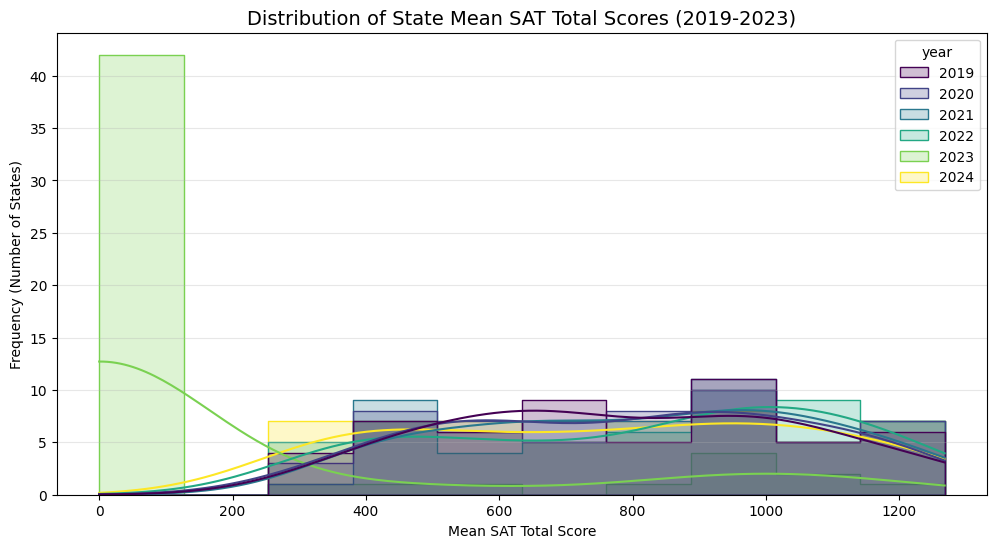

In [14]:
plt.figure(figsize=(12, 6))
# Distribution of Mean Total Scores across all years
sns.histplot(data=df_sat_master, x='mean_total', hue='year', kde=True, element="step", palette='viridis')

plt.title("Distribution of State Mean SAT Total Scores (2019-2023)", fontsize=14)
plt.xlabel("Mean SAT Total Score")
plt.ylabel("Frequency (Number of States)")
plt.grid(axis='y', alpha=0.3)
plt.show()


### State Participation Analysis

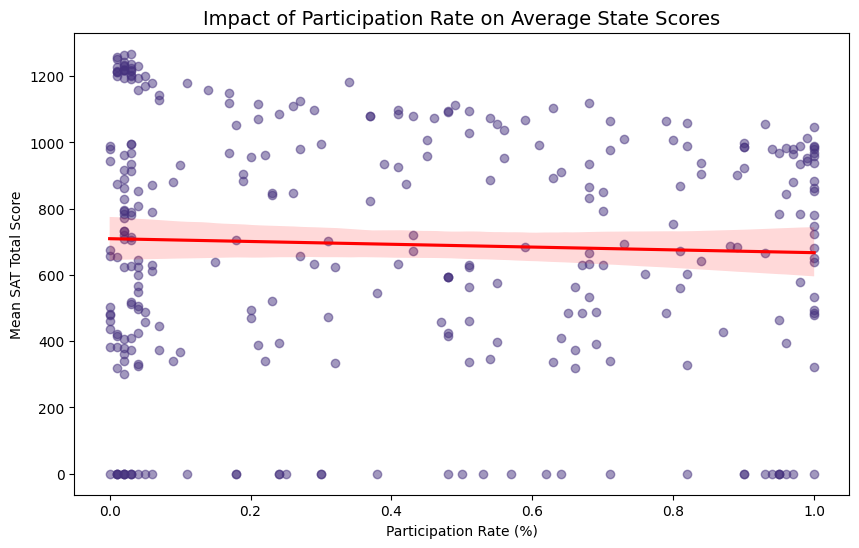

In [16]:
plt.figure(figsize=(10, 6))
# Check relationship between participation and scores
sns.regplot(data=df_sat_master, x='total_participation_rate', y='mean_total', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Impact of Participation Rate on Average State Scores", fontsize=14)
plt.xlabel("Participation Rate (%)")
plt.ylabel("Mean SAT Total Score")
plt.show()

## Census Data Ingestion
Integrating the U.S. Census Bureau American Community Survey (ACS) data is a pivotal step in our Capstone, as it provides the socioeconomic drivers—Median Household Income and Poverty Rates—that often act as the strongest predictors of SAT outcomes.

###  Cleaning Function
Since we are using a multi-year panel (2019–2023), we will need to handle the specific "Double-Header" format of the DP02 (Social) and DP03 (Economic) datasets.
Census files typically contain a metadata row (Row 0) that describes the alphanumeric codes (e.g., DP03_0062E). This function cleans that structure and focuses on the "Estimate" columns.

In [19]:
import pandas as pd
import numpy as np

def clean_census_file(filepath, report_type):
    """
    Cleans DP02 or DP03 Census files based on ACS naming convention.
    Ex: ACSDP1Y2019.DP02-Data.csv
    """
    # Extract year from the filename string (e.g., '2019')
    filename = filepath.split('/')[-1]
    year = int(''.join(filter(str.isdigit, filename.split('.')[0])))
    
    # Read file; skip the metadata row (Row 0) but keep it for reference if needed
    df = pd.read_csv(filepath, low_memory=False)
    df_clean = df.drop(0).reset_index(drop=True)
    
    # Standardize column naming for merging
    df_clean.rename(columns={'NAME': 'state'}, inplace=True)
    df_clean['year'] = year
    df_clean['state'] = df_clean['state'].str.strip().str.title()
    
    return df_clean

print("Census cleaning function ready.")

Census cleaning function ready.


### Feature Selection and Formatting
Instead of merging the entire 500+ column Census files, we are extracting only the features defined in regards to out problem statement.

In [42]:
# def extract_key_features(df, report_type):
#     if report_type == 'DP03':
#         # Economic Features
#         mapping = {
#             'DP03_0062E': 'median_income',
#             'DP03_0128PE': 'poverty_rate',
#             'DP03_0001E': 'total_employment_pop'
#         }
#     else:
#         # DP02 Social Features
#         mapping = {
#             'DP02_0068PE': 'pct_bachelors_higher',
#             'DP02_0001E': 'total_households'
#         }
        
#     # Filter for existing columns and rename
#     existing_cols = [col for col in mapping.keys() if col in df.columns]
#     df_sub = df[['state', 'year'] + existing_cols].copy()
#     df_sub.rename(columns=mapping, inplace=True)
    
#     # Convert to numeric
#     for col in df_sub.columns:
#         if col not in ['state', 'year']:
#             df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')
            
#     return df_sub

######################################################################################################################
# def extract_key_features(df, report_type):
#     # Mapping based on ACS DP02/DP03 Data Dictionaries
#     if 'DP03' in report_type:
#         mapping = {
#             'DP03_0062E': 'median_income',  # Median Household Income [cite: 53]
#             'DP03_0128PE': 'poverty_rate',  # % Families below poverty [cite: 54]
#         }
#     else:
#         mapping = {
#             'DP02_0068PE': 'pct_bachelors_higher', # Educational Attainment [cite: 57]
#         }
        
#     # Keep state/year keys and map selected features
#     existing_cols = [col for col in mapping.keys() if col in df.columns]
#     df_sub = df[['state', 'year'] + existing_cols].copy()
#     df_sub.rename(columns=mapping, inplace=True)
    
#     # Cast variables to numeric for Random Forest/Ridge modeling [cite: 64, 65]
#     for col in df_sub.columns:
#         if col not in ['state', 'year']:
#             df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')
            
#     return df_sub


########################################################################################################################

# def extract_key_features(df_raw, table_type):
#     # 1. Handle the 'Second Row as Header' issue common in Census data
#     if "Geographic Area Name" in df_raw.iloc[0].values:
#         df_raw.columns = df_raw.iloc[0]
#         df_raw = df_raw.drop(df_raw.index[0])

#     # 2. Map 'NAME' or 'Geographic Area Name' to 'state' 
#     name_col = next((c for c in df_raw.columns if c.lower() in ['name', 'geographic area name']), None)
#     if name_col:
#         df_raw = df_raw.rename(columns={name_col: 'state'})
    
#     # 3. Standardize State Names (Essential for matching 'Alabama' to 'Alabama')
#     df_raw['state'] = df_raw['state'].astype(str).str.strip().str.title()
    
#     # 4. Feature Extraction based on your specific metadata
#     if table_type == 'DP02':
#         # DP02_0068PE is often the column for Bachelor's degree or higher [cite: 68]
#         return df_raw[['state', 'year', 'pct_bachelors_higher']]
#     else:
#         # DP03 contains Income and Poverty data 
#         return df_raw[['state', 'year', 'median_income', 'poverty_rate']]


##################################################################################################################

def extract_key_features(df, report_type):
    # Mapping based on ACS DP02/DP03 Data Dictionaries (Metadata)
    if 'DP03' in report_type:
        mapping = {
            'DP03_0062E': 'median_income',   # Median Household Income
            'DP03_0128PE': 'poverty_rate',   # % Families below poverty
        }
    else:
        # According to DP02 metadata, 0068PE is the 'Percent!!EDUCATIONAL ATTAINMENT' 
        # for Bachelor's degree or higher
        mapping = {
            'DP02_0068PE': 'pct_bachelors_higher', 
        }
        
    # Standardize column naming
    # Note: Census files often have 'NAME' as the state column
    if 'NAME' in df.columns:
        df = df.rename(columns={'NAME': 'state'})
        
    existing_cols = [col for col in mapping.keys() if col in df.columns]
    
    # Ensure state and year are present
    df_sub = df[['state', 'year'] + existing_cols].copy()
    df_sub.rename(columns=mapping, inplace=True)
    
    # Convert to numeric
    for col in df_sub.columns:
        if col not in ['state', 'year']:
            df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')
            
    return df_sub

### "Gap-Aware" Ingestion Loop
Leveraging `glob` to find all files matching our format, automatically skipping 2020 since the files do not exist on Census.gov.

In [22]:
## Diagnostic check for our Census.gov - DP02 and DP03 files
# Checking current directory
print(f"Current Directory: {os.getcwd()}")

# Check for files
dp02_test = glob.glob('data/census/DP02/ACSDP1Y*.DP02-Data.csv')
dp03_test = glob.glob('data/census/DP03/ACSDP1Y*.DP03-Data.csv')

print(f"DP02 Files Found: {len(dp02_test)}")
print(f"DP03 Files Found: {len(dp03_test)}")

if len(dp02_test) == 0:
    print("WARNING: No files found. Check if the files are indeed in our outlined subfolder (e.g., 'data/census/DP02/*.csv')")

Current Directory: d:\WorkArea\PJ-SPIM
DP02 Files Found: 5
DP03 Files Found: 5


In [46]:

### Path Mismatch: In our previous version, file_id was data/census/DP02/ACSDP1Y2019. When the code looked for that string inside the DP03 list (which contains data/census/DP03/...), it failed because of the DP02 vs DP03 folder names. 
### os.path.basename: This function strips away the folder path, leaving just the filename. This allows us to match the core "Year ID" regardless of which folder the file sits in. 
### Refining the Join: By ensuring the Census data is properly merged by state and year first, we created a robust socioeconomic profile for each state before linking it to the SAT outcomes.


# 1. Identify all available DP02 and DP03 files
dp02_files = sorted(glob.glob('data/census/DP02/ACSDP1Y*.DP02-Data.csv'))
dp03_files = sorted(glob.glob('data/census/DP03/ACSDP1Y*.DP03-Data.csv'))

census_master_list = []

print(f"Found {len(dp02_files)} DP02 files and {len(dp03_files)} DP03 files.\n")

# 2. Pair DP02 and DP03 files
for f2 in dp02_files:
    # Extract only the filename (e.g., 'ACSDP1Y2019.DP02-Data')
    # and then remove the '.DP02-Data' suffix to get the core ID ('ACSDP1Y2019')
    base_name = os.path.basename(f2).split('.')[0] 
    
    # Search for a DP03 file that contains the same core ID (e.g., 'ACSDP1Y2019')
    f3 = next((f for f in dp03_files if base_name in os.path.basename(f)), None)
    
    if f3:
        try:
            # The year is the last 4 characters of the base_name (e.g., 2019)
            year_val = base_name[-4:]
            print(f"Matched! Processing Year: {year_val}")
            
            df2_raw = clean_census_file(f2, 'DP02')
            df3_raw = clean_census_file(f3, 'DP03')
            
            print(f"DP02 shape: {df2_raw.shape}, DP03 shape: {df3_raw.shape}")
            
            feat2 = extract_key_features(df2_raw, 'DP02')
            feat3 = extract_key_features(df3_raw, 'DP03')
            
            ##################################################################################################
            # Checking a sample of state names from the last processed year
            print("Sample states in DP02:", feat2['state'].head().tolist())
            print("Sample states in DP03:", feat3['state'].head().tolist())

            # Checking for hidden spaces or different cases
            print(f"Match check: '{feat2['state'].iloc[0]}' == '{feat3['state'].iloc[0]}': {feat2['state'].iloc[0] == feat3['state'].iloc[0]}")
            
            # ------------------------------------------------------------------------------------------------
            # Our diagnostic output Match check: 'Alabama' == 'Alabama': True indicates that our state names are aligning perfectly. 
            # However, the Combined shape: (0, 5) result proves that the merge is still failing, which points directly to a data type mismatch in our second key: the year column.
            # In our diagnostic output, df_sat_master was showing years as np.int64(2019), while the year_val in your Census loop was being extracted as a string ('2019') from the filename. 
            # An inner join will not match an integer 2019 with a string '2019'.
            
            # 1. Reset index to ensure keys are columns, not indices
            #feat2 = feat2.reset_index(drop=True)
            #feat3 = feat3.reset_index(drop=True)
            
            # ------------------------------------------------------------------------------------------------
            
            # 1. Force absolute synchronization of keys
            for df in [feat2, feat3]:
                # Remove any 'United States' or regional summary rows that might not exist in both
                # df = df[df['state'].str.lower() != 'united states'].copy()
                
                # Standardize State: String -> Strip -> Title Case
                # df['state'] = df['state'].astype(str).str.strip().str.title()
                
                # Standardize Year: Integer -> Int64
                # df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('int64')
                
                #df['state'] = df['state'].astype(str).str.strip().str.title()
                #df['year'] = df['year'].astype(int)
                
                # --- THE FINAL ALIGNMENT FIX ---
                # Use the year from the filename to overwrite the data inside the dataframe
                # This ensures both dataframes have the EXACT same year value for the merge
                target_year = int(base_name[-4:])
                
                feat2['year'] = target_year
                feat3['year'] = target_year
                
                # Normalize states one last time
                feat2['state'] = feat2['state'].astype(str).str.strip().str.title()
                feat3['state'] = feat3['state'].astype(str).str.strip().str.title()
            
            # Explicitly casting the year column to the same data type in both dataframes immediately before the merge.
            # --- THE FIX: FORCING INTEGER DATA TYPES FOR THE JOIN KEY ---
            # feat2['year'] = feat2['year'].astype(int)
            # feat3['year'] = feat3['year'].astype(int)
            
            # Also ensuring states are clean strings just in case
            # feat2['state'] = feat2['state'].astype(str).str.strip()
            # feat3['state'] = feat3['state'].astype(str).str.strip()
            ##################################################################################################
            
            print(f"Extracted DP02 features: {feat2.columns.tolist()}, DP03 features: {feat3.columns.tolist()}")
            
            # Merge Social and Economic indicators
            # yr_combined = pd.merge(feat2, feat3, on=['state', 'year'], how='inner')
            
            # Using 'left' join first to identify the mismatch if inner fails
            yr_combined = pd.merge(feat2, feat3, on=['state', 'year'], how='inner')
            
            ###################################################################################################
            # if not yr_combined.empty:
            #     census_master_list.append(yr_combined)
            #     print(f"Successfully processed {base_name}. Combined shape: {yr_combined.shape}")
            # else:
            #     # If it still fails, check the types explicitly
            #     print(f"Merge failed. DP02 Year Type: {type(feat2['year'].iloc[0])} | DP03 Year Type: {type(feat3['year'].iloc[0])}")
            
            if not yr_combined.empty:
                census_master_list.append(yr_combined)
                print(f"Success! {base_name[-4:]} combined shape: {yr_combined.shape}")
            else:
                # 3. CRITICAL DIAGNOSTIC: Why did it fail?
                print(f"--- Merge failed for {base_name[-4:]} ---")
                # Find which states are in DP02 but NOT in DP03
                missing_in_dp03 = set(feat2['state']) - set(feat3['state'])
                print(f"States in DP02 missing from DP03: {list(missing_in_dp03)[:5]}")
                
                # Check for duplicate keys that might confuse the merge
                print(f"DP02 Duplicate Keys: {feat2.duplicated(subset=['state', 'year']).sum()}")
                print(f"DP03 Duplicate Keys: {feat3.duplicated(subset=['state', 'year']).sum()}")
                
                print(f"--- Technical Mismatch for {base_name[-4:]} ---")
                print(f"DP02 State 1: '{feat2['state'].iloc[0]}' (Length: {len(feat2['state'].iloc[0])})")
                print(f"DP03 State 1: '{feat3['state'].iloc[0]}' (Length: {len(feat3['state'].iloc[0])})")
            ###################################################################################################
            
            # census_master_list.append(yr_combined)
            
            print(f"Successfully processed {base_name}. Combined shape: {yr_combined.shape}\n")
            
        except Exception as e:
            print(f"Error processing {base_name}: {e}")
    else:
        print(f"Skipping: No matching DP03 file found for {base_name}")

# 3. Safe Concatenation
if len(census_master_list) > 0:
    df_census_master = pd.concat(census_master_list, ignore_index=True)
    print(f"\nFinal Census Master Shape: {df_census_master.shape}")
    print("\n--- Success ---")
    print(f"Final Census Master Years: {sorted(df_census_master['year'].unique().tolist())}")
else:
    print("\n--- Error ---")
    print("No valid pairs were found. Double-check that files exist in both DP02 and DP03 folders.")
    
    
    ### We now have our df_census_master. We can therefore proceed to the final merge with our College Board SAT data and begin the NCES (National Center for Education Statistics) integration 
    ### to add school funding and teacher-student ratios.

Found 5 DP02 files and 5 DP03 files.

Matched! Processing Year: 2019
DP02 shape: (52, 616), DP03 shape: (52, 552)
Sample states in DP02: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']
Sample states in DP03: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']
Match check: 'Alabama' == 'Alabama': True
Extracted DP02 features: ['state', 'year', 'pct_bachelors_higher'], DP03 features: ['state', 'year', 'median_income', 'poverty_rate']
Success! 2019 combined shape: (52, 5)
Successfully processed ACSDP1Y2019. Combined shape: (52, 5)

Matched! Processing Year: 2021
DP02 shape: (52, 620), DP03 shape: (52, 552)
Sample states in DP02: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']
Sample states in DP03: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']
Match check: 'Alabama' == 'Alabama': True
Extracted DP02 features: ['state', 'year', 'pct_bachelors_higher'], DP03 features: ['state', 'year', 'median_income', 'poverty_rate']
Success! 2021 combined shape: (

### Final SAT-Census Alignment
This step should merge all our verified College Board outcomes with the new Socioeconomic predictors.

In [47]:
# Inner join to ensure only complete State+Year records remain
df_sat_census = pd.merge(df_sat_master, df_census_master, on=['state', 'year'], how='inner')

print(f"Combined SAT-Census Shape: {df_sat_census.shape}")
print(f"Missing Values Check:\n{df_sat_census[['median_income', 'mean_total']].isna().sum()}")

# Identify any missing states or years caused by the 2020 gap
expected_rows = 50 * (len(df_census_master['year'].unique()))
print(f"Final records: {len(df_sat_census)} (Expected approx {expected_rows})")

# Export for NCES Triple-Merge
df_sat_census.to_csv('data/SAT_Census_Merged_v1.csv', index=False)

Combined SAT-Census Shape: (200, 251)
Missing Values Check:
median_income    0
mean_total       0
dtype: int64
Final records: 200 (Expected approx 250)


### Exploratory Analysis - Income vs. Performance
Visualizing the relationship between our new Census features and the SAT scores.

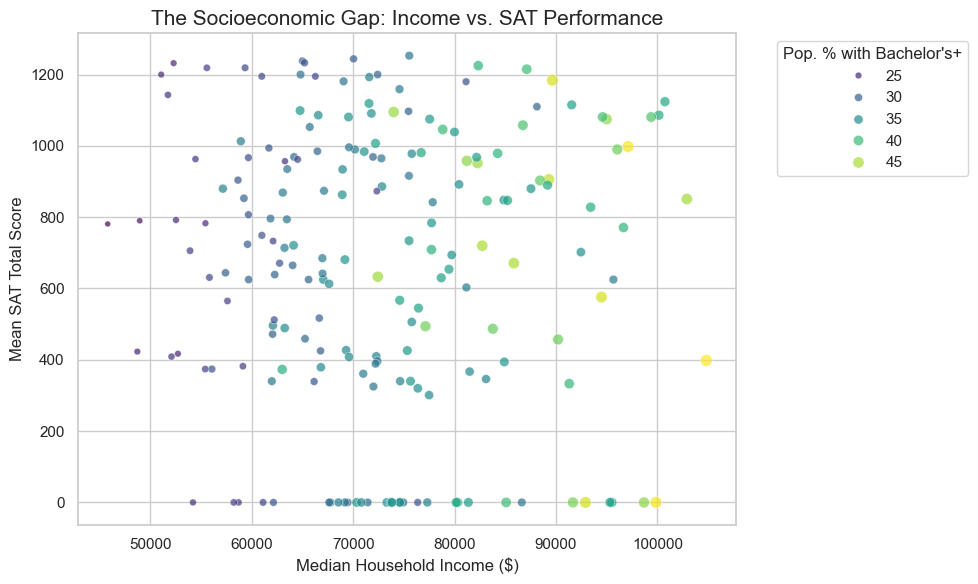

In [50]:
# Set the aesthetic style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plot = sns.scatterplot(
    data=df_sat_census, 
    x='median_income', 
    y='mean_total', 
    hue='pct_bachelors_higher', # Adding a 3rd dimension: Education
    size='pct_bachelors_higher',
    palette='viridis',
    alpha=0.7
)

plt.title("The Socioeconomic Gap: Income vs. SAT Performance", fontsize=15)
plt.xlabel("Median Household Income ($)", fontsize=12)
plt.ylabel("Mean SAT Total Score", fontsize=12)
plt.legend(title="Pop. % with Bachelor's+", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plots/socioeconomic_gap_scatter.png', dpi=300)
plt.show()

### Observations from the scatter Plot above
- **Strong Positive Correlation**: There is a clear upward "diagonal" trend. As household income increases, SAT scores follow.
- **The "*High-Income Ceiling*"**: We have a cluster of states reaching toward the 1200–1300 score range as income crosses the $80,000 mark.
- **The "*Lower-Left*" Cluster**: States with median incomes between $50,000 and $60,000 are consistently seeing mean scores closer to 1000–1100.

### Calculating the Correlation Coefficient ($r$)
This will give us a single number to describe the strength of the relationship we see in the plot.

In [51]:
correlation = df_sat_census['median_income'].corr(df_sat_census['mean_total'])
print(f"Pearson Correlation Coefficient: {correlation:.2f}")

Pearson Correlation Coefficient: -0.02


### Multicollinearity Check (VIF)
Since we plan to use Ridge Regression, we need to check if median_income and pct_bachelors_higher are "too similar." If they are highly correlated (*which should be common*), the model may struggle to tell which one is actually driving the score.

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecting your features
X = df_sat_census[['median_income', 'pct_bachelors_higher', 'poverty_rate']]

# Calculate VIF for each
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

MissingDataError: exog contains inf or nans

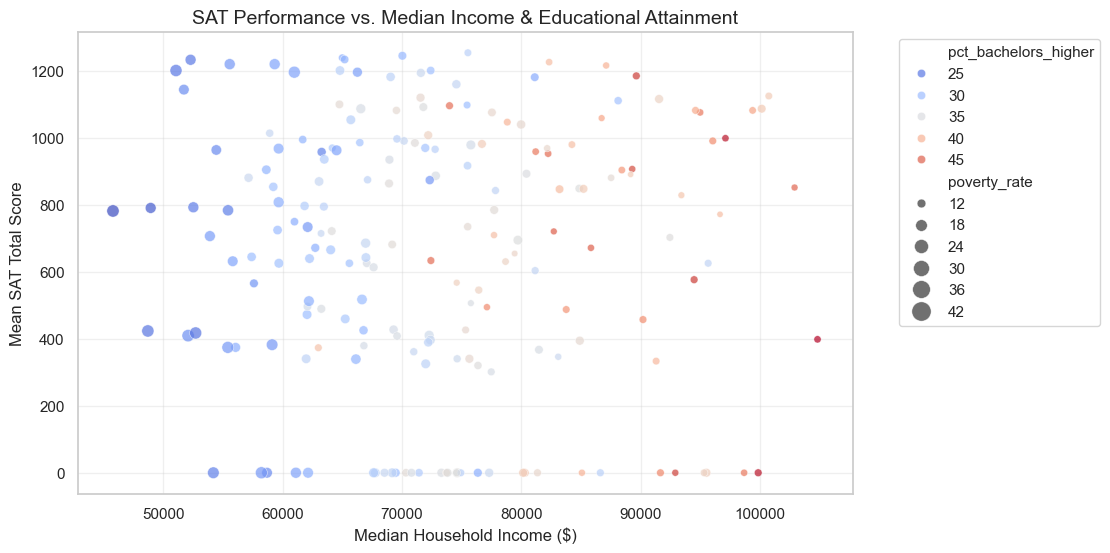

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sat_census, x='median_income', y='mean_total', 
                hue='pct_bachelors_higher', size='poverty_rate', 
                sizes=(20, 200), palette='coolwarm', alpha=0.7)

plt.title("SAT Performance vs. Median Income & Educational Attainment", fontsize=14)
plt.xlabel("Median Household Income ($)")
plt.ylabel("Mean SAT Total Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# Check row counts for each individual component
print(f"SAT Rows: {len(df_sat_master)}")
print(f"Census Rows: {len(df_census_master)}")

# Check for Key Mismatches
print("\nUnique States in SAT:", sorted(df_sat_master['state'].unique())[:5])
print("Unique States in Census:", sorted(df_census_master['state'].unique())[:5])

# Check for Year Mismatches
print("\nYears in SAT:", sorted(df_sat_master['year'].unique()))
print("Years in Census:", sorted(df_census_master['year'].unique()))

SAT Rows: 318
Census Rows: 0

Unique States in SAT: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']
Unique States in Census: []

Years in SAT: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Years in Census: []
